# Consumer Insight Mining via Unstructured Web Data

This project applies NLP and statistical methods to extract consumer insights from car forum discussions scraped from the Edmunds entry-level luxury sedan thread. The corpus contains roughly 5,000 posts spanning multiple years of organic discussion.

The analysis proceeds through six stages:

1. **Zipf's Law validation**: confirming the corpus follows a power-law word frequency distribution via OLS regression
2. **Brand frequency analysis**: identifying the most-discussed brands after normalizing model names to parent brands
3. **Co-mention lift analysis**: measuring how often brand pairs appear near each other relative to chance, using a proximity constraint
4. **MDS brand mapping**: projecting brand association distances into 2D space for visual interpretation
5. **Attribute-brand lift**: identifying which attributes (performance, price, comfort, etc.) are most strongly associated with each brand
6. **Aspirational brand detection**: using bigram phrase matching to find which brands consumers express desire or aspiration toward

**Data source:** Edmunds.com forums, entry-level luxury performance sedans thread

In [1]:
import re
import string
import warnings
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.manifold import MDS
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')

# ── File paths ────────────────────────────────────────────────────────────────
RAW_CSV       = 'edmunds_raw.csv'
BRAND_MAP_CSV = 'car_models_and_brands.csv'

# ── Brand universe ────────────────────────────────────────────────────────────
# Includes discontinued brands (Pontiac, Saturn, Mercury, Suzuki) because they
# appear in the corpus from posts predating their discontinuation.
BRANDS = {
    'acura', 'audi', 'bmw', 'buick', 'cadillac', 'chevrolet', 'chrysler',
    'dodge', 'ford', 'honda', 'hyundai', 'infiniti', 'kia', 'lincoln',
    'lexus', 'mazda', 'mercedes', 'mercury', 'mitsubishi', 'nissan',
    'pontiac', 'saturn', 'subaru', 'suzuki', 'toyota', 'volkswagen', 'volvo'
}

# Strip hyphens/dots so tokens like "vw" still map correctly after punctuation removal
BRAND_LOOKUP = {re.sub(r'[\s\-\.]', '', b).lower(): b for b in BRANDS}

# ── Shared utilities ──────────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))

def tokenize(text):
    """Lowercase, strip punctuation, split on whitespace."""
    if not isinstance(text, str):
        return []
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text.lower())
    return text.split()

def brands_in_tokens(tokens):
    """Return the set of brand names present in a token list."""
    return {BRAND_LOOKUP[t] for t in tokens if t in BRAND_LOOKUP}

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Data Collection

The raw data was collected once using a Selenium scraper targeting the Edmunds entry-level luxury performance sedan forum thread. The code below is shown for reproducibility but does **not** need to be re-run — the scraped CSV is loaded directly in the next section.

The scraper paginates through 200 pages of the thread, extracting the post date and comment body from each forum entry. Posts are saved to `data/edmunds_raw.csv`.

```python
# ── Scraper (reference only — requires Microsoft Edge + msedgedriver) ─────────

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.edge.options import Options as EdgeOptions
import time
import pandas as pd

FORUM_URL  = 'https://forums.edmunds.com/discussion/2864/general/x/entry-level-luxury-performance-sedans'
NUM_PAGES  = 200
SLEEP_SECS = 10  # polite crawl delay per page

class EdmundsScraper:
    def __init__(self):
        options = EdgeOptions()
        options.add_experimental_option('excludeSwitches', ['enable-logging'])
        self.driver = webdriver.Edge(options=options)
        self.dates, self.texts = [], []

    def scrape(self):
        for page in range(1, NUM_PAGES + 1):
            url = f'{FORUM_URL}/p{page}'
            self.driver.get(url)
            time.sleep(SLEEP_SECS)
            for post in self.driver.find_elements(By.CLASS_NAME, 'Comment'):
                self.dates.append(post.find_element(By.CLASS_NAME, 'Permalink').text)
                self.texts.append(post.find_element(By.CLASS_NAME, 'Message.userContent').text)

    def to_dataframe(self):
        return pd.DataFrame({'date': self.dates, 'comment': self.texts})

scraper = EdmundsScraper()
scraper.scrape()
scraper.to_dataframe().to_csv('data/edmunds_raw.csv', index=False)
```

## 2. Data Loading and Preprocessing

Before any analysis, three preprocessing steps are applied:

1. **Model-to-brand normalization**: car model names (e.g. "Camry", "3 Series") are replaced with their parent brand using a lookup table, so all downstream analysis operates on brand tokens only
2. **Text cleaning**: punctuation removed, text lowercased, whitespace collapsed
3. **Two corpus variants are retained:**
   - Full corpus including stopwords: used only for Zipf's Law validation, which requires the unfiltered word distribution
   - Stopword-filtered corpus: used for all frequency and lift analyses

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_CSV)

# Normalize column names to lowercase to handle whatever casing the CSV has
df.columns = df.columns.str.strip().str.lower()
df['comment'] = df['comment'].astype(str)

# ── Load model->brand replacement map ────────────────────────────────────────
brand_map_df   = pd.read_csv(BRAND_MAP_CSV)
MODEL_TO_BRAND = {
    row['Model'].lower(): row['Brand'].lower()
    for _, row in brand_map_df.iterrows()
}

# ── Apply model->brand replacement ───────────────────────────────────────────
def replace_models(text):
    """Replace car model tokens with their parent brand name."""
    if not isinstance(text, str):
        return text
    words = text.split()
    return ' '.join(MODEL_TO_BRAND.get(re.sub(r'[^\w\s]', '', w.lower()), w) for w in words)

df['comment_normalized'] = df['comment'].apply(replace_models)

# ── Clean text ────────────────────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^\w\s]', '', text).lower()
    return re.sub(r'\s+', ' ', text).strip()

df['comment_clean'] = df['comment_normalized'].apply(clean_text)

# ── Build corpus strings ──────────────────────────────────────────────────────
all_comments   = ' '.join(df['comment_clean'])
corpus_no_stop = ' '.join(w for w in all_comments.split() if w not in STOP_WORDS)

# ── Post-level token lists ────────────────────────────────────────────────────
df['tokens']       = df['comment_clean'].apply(tokenize)
df['tokens_clean'] = df['tokens'].apply(
    lambda toks: [t for t in toks if t not in STOP_WORDS]
)

# N_POSTS is used as the population size N in all lift calculations
N_POSTS = len(df)

print(f"Posts loaded:           {N_POSTS:,}")
print(f"Total tokens (raw):     {len(all_comments.split()):,}")
print(f"Total tokens (no stop): {len(corpus_no_stop.split()):,}")

Posts loaded:           10,000
Total tokens (raw):     917,595
Total tokens (no stop): 493,329


## 3. Zipf's Law Validation

Zipf's law states that in a natural language corpus, the frequency of any word is inversely proportional to its rank in the frequency table. To test this econometrically, we estimate the following log-linear model with no intercept:

    ln(rank) = theta * ln(frequency / f_min) + epsilon

where f_min is the frequency of the least common word. Under a strict Zipf distribution, the estimate of theta should equal -1. Stopwords are retained for this analysis because Zipf's law describes the full unfiltered word distribution.

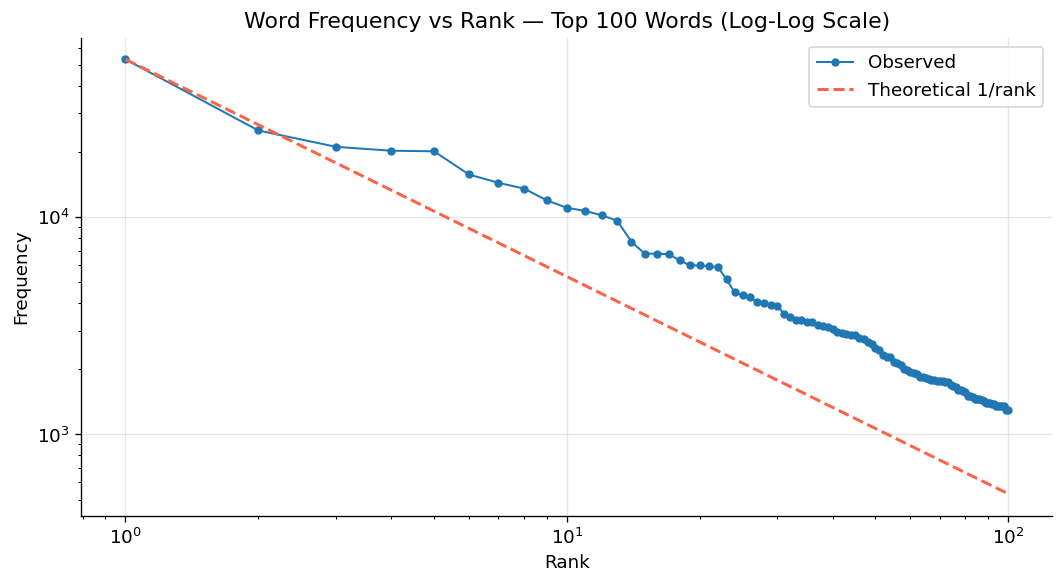

                                 OLS Regression Results                                
Dep. Variable:                ln_rank   R-squared (uncentered):                   0.238
Model:                            OLS   Adj. R-squared (uncentered):              0.238
Method:                 Least Squares   F-statistic:                              9387.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                        0.00
Time:                        18:40:02   Log-Likelihood:                     -1.0603e+05
No. Observations:               30119   AIC:                                  2.121e+05
Df Residuals:                   30118   BIC:                                  2.121e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [3]:
# ── Word frequency counts (with stopwords, for Zipf) ─────────────────────────
word_counts_raw = Counter(all_comments.split())
counts_sorted   = np.array(sorted(word_counts_raw.values(), reverse=True))
ranks           = np.arange(1, len(counts_sorted) + 1)

# ── Plot: observed vs theoretical Zipf (top 100 words) ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(ranks[:100], counts_sorted[:100],
          marker='o', ms=4, lw=1.2, label='Observed')
ax.loglog(ranks[:100], counts_sorted[0] / ranks[:100],
          lw=1.8, color='tomato', ls='--', label='Theoretical 1/rank')
ax.set_xlabel('Rank')
ax.set_ylabel('Frequency')
ax.set_title('Word Frequency vs Rank — Top 100 Words (Log-Log Scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── OLS regression to estimate theta ─────────────────────────────────────────
# Regress ln(rank) on ln(f_min / frequency) with no intercept.
# As rank increases, frequency decreases, so ln(f_min/freq) increases with rank.
# theta = -1 is the theoretical Zipf prediction when formulated as
# ln(freq) ~ -1 * ln(rank), equivalently ln(rank) ~ -1 * ln(freq/f_min).
f_min    = counts_sorted[-1]
term_log = np.log(f_min / counts_sorted)  # increases monotonically with rank
data_zip = pd.DataFrame({'ln_rank': np.log(ranks), 'term': term_log})

model_zip = smf.ols('ln_rank ~ 0 + term', data=data_zip).fit()
print(model_zip.summary())

## Zipf's Law: Interpretation

The log-log plot shows that the observed word frequency distribution follows a power-law decay broadly consistent with Zipf's law, but with notable deviation. The estimated theta is -2.61 (95% CI: [-2.67, -2.56], p < 0.001), which is statistically significant but meaningfully different from the theoretical value of -1.

This deviation is expected for a domain-specific corpus. The Edmunds forum vocabulary is narrow and repetitive. A small set of car-related terms (brand names, model descriptors, performance vocabulary) accumulates far more frequency mass than the same ranks would in general English. This compresses the mid-frequency range and steepens the rank-frequency slope beyond what pure Zipf predicts.

The key takeaway is that the corpus does follow a power-law distribution, confirming it exhibits the statistical structure of natural language. The deviation from theta = -1 is a property of the domain, not a data quality issue.

## 4. Brand Frequency Analysis

We count how many posts mention each brand, with one deduplication rule: even if a brand appears multiple times in a single post, it is counted once. This measures breadth of discussion rather than volume of repetiti. For example, — a brand mentioned briefly in 500 posts is treated differently from one obsessed over in 50 posts.

Model names have already been normalized to parent brands in the preprocessing step, so mentions of "Camry" or "Corolla" are counted toward Toyota.

Top 10 brands by post-level mention count:
  bmw             3,100 posts
  lexus           1,124 posts
  acura             931 posts
  audi              916 posts
  honda             758 posts
  infiniti          674 posts
  toyota            638 posts
  nissan            426 posts
  mercedes          345 posts
  cadillac          339 posts


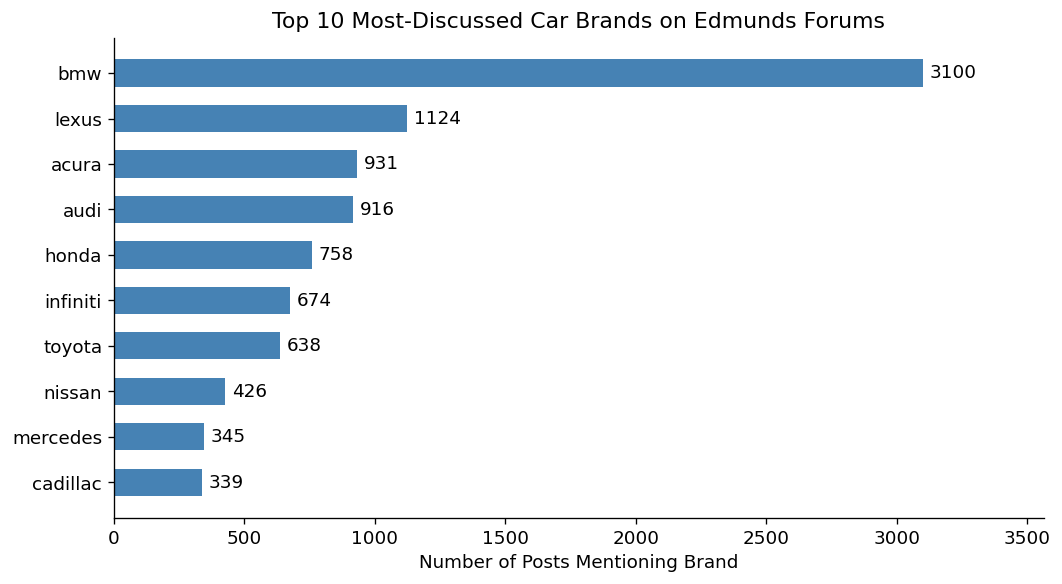

In [4]:
# ── Count brand mentions per post (deduplicated within each post) ─────────────
brand_post_counts = Counter()
for tokens in df['tokens']:
    for brand in brands_in_tokens(tokens):
        brand_post_counts[brand] += 1

# ── Top 10 brands ─────────────────────────────────────────────────────────────
top_10       = [b for b, _ in brand_post_counts.most_common(10)]
top_10_counts = [brand_post_counts[b] for b in top_10]

print("Top 10 brands by post-level mention count:")
for brand, count in zip(top_10, top_10_counts):
    print(f"  {brand:<15} {count:>5,} posts")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
top_10_display = [b.title() for b in top_10]
bars = ax.barh(top_10[::-1], top_10_counts[::-1], color='steelblue', height=0.6)
ax.bar_label(bars, padding=4, fmt='%d')
ax.set_xlabel('Number of Posts Mentioning Brand')
ax.set_title('Top 10 Most-Discussed Car Brands on Edmunds Forums')
ax.set_xlim(0, max(top_10_counts) * 1.15)
plt.tight_layout()
plt.show()

## 5. Brand Co-mention Lift Analysis

Lift measures how much more often two brands are mentioned together than would be expected if they were independent:

    lift(A, B) = (posts mentioning both A and B * N) / (posts mentioning A * posts mentioning B)

A lift value above 1 means the two brands are discussed together more than chance; below 1 means they rarely appear in the same context.

**Proximity constraint:** A co-mention is only counted if the two brand tokens appear within 5 words of each other in the post. This filters out posts that mention two brands in completely separate cng post.

The lift matrix is computed across all brands in the universe, then filtered to the top 10 for visualization.

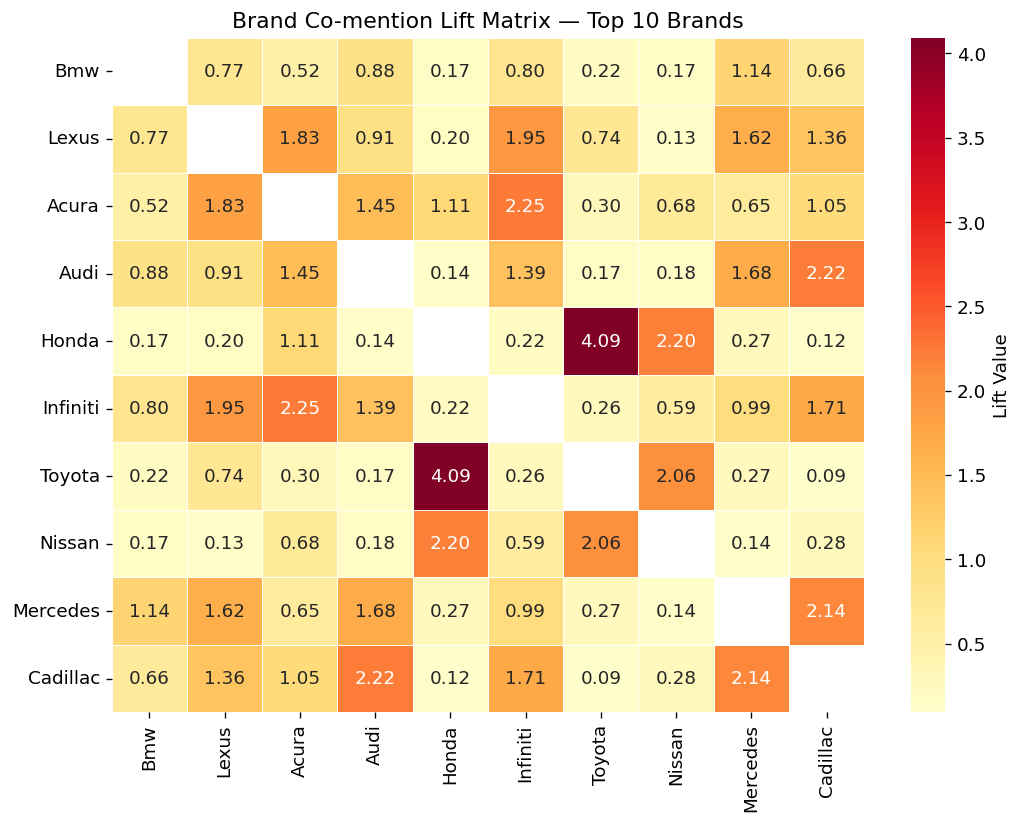

In [5]:
PROXIMITY = 5  # max token distance between two brand mentions to count as co-mention

post_brand_freq = defaultdict(int)  # posts mentioning brand X
post_pair_freq  = defaultdict(int)  # posts where brands X and Y appear within PROXIMITY words

for _, row in df.iterrows():
    tokens = row['tokens']

    # Find all brand positions in this post
    brand_positions = []
    for i, token in enumerate(tokens):
        if token in BRAND_LOOKUP:
            brand_positions.append((BRAND_LOOKUP[token], i))

    # Deduplicated brand set for individual frequency counts
    seen = set(b for b, _ in brand_positions)
    for b in seen:
        post_brand_freq[b] += 1

    # Proximity-filtered pair counts
    for (b1, p1), (b2, p2) in combinations(brand_positions, 2):
        if b1 != b2 and abs(p1 - p2) <= PROXIMITY:
            pair_key = tuple(sorted([b1, b2]))
            post_pair_freq[pair_key] += 1

# ── Build full lift matrix ────────────────────────────────────────────────────
all_brands_seen = sorted(post_brand_freq.keys())

lift_matrix = pd.DataFrame(
    np.zeros((len(all_brands_seen), len(all_brands_seen))),
    index=all_brands_seen,
    columns=all_brands_seen
)

for (b1, b2), pair_count in post_pair_freq.items():
    if post_brand_freq[b1] > 0 and post_brand_freq[b2] > 0:
        lift = (pair_count * N_POSTS) / (post_brand_freq[b1] * post_brand_freq[b2])
        lift_matrix.loc[b1, b2] = lift
        lift_matrix.loc[b2, b1] = lift

# ── Filter to top 10 ──────────────────────────────────────────────────────────
lift_top10 = lift_matrix.loc[top_10, top_10]

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(top_10), dtype=bool)  # mask diagonal — self-lift is undefined
sns.heatmap(
    lift_top10.rename(index=str.title, columns=str.title),
    mask=mask, annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Lift Value'}
)
ax.set_title('Brand Co-mention Lift Matrix — Top 10 Brands')
plt.tight_layout()
plt.show()

Two distinct brand clusters emerge from the lift matrix.

The first is a Japanese mainstream cluster: Honda, Toyota, and Nissan show the highest pairwise lift values in the entire matrix (Honda-Toyota: 4.09, Honda-Nissan: 2.20, Toyota-Nissan: 2.06). Forum users frequently compare these three in the same breath, treating them as direct substitutes despite none being traditional luxury brands. Their presence in this thread reflects consumers anchoring luxury comparisons against reliable, value-oriented alternatives.

The second is a Japanese luxury cluster: Lexus, Acura, and Infiniti show consistently elevated lift with each other (Lexus-Acura: 1.83, Lexus-Infiniti: 1.95, Acura-Infiniti: 2.25), suggesting consumers shopping one are actively cross-shopping the others.

BMW is the most-discussed brand by post volume but shows relatively low lift with most other brands. This indicates BMW is frequently mentioned as a standalone benchmark rather than in direct comparison. When consumers reference BMW, they tend to be using it as a reference point, not evaluating it against a specific competitor.

Cadillac's strongest associations are with Audi (2.22) and Mercedes (2.14) rather than with other domestic brands, suggesting forum users place it in the European luxury competitive set rather than a domestic one.

## 6. MDS Brand Association Map

Multi-dimensional scaling (MDS) projects the pairwise brand distances into two dimensions for visual interpretation. Distance is defined as the inverse of lift: brands with high co-mention lift are placed close together; brands rarely discussed together are placed far apart. A small epsilon is added before inversion to avoid division by zero for brand pairs with no co-mentions.

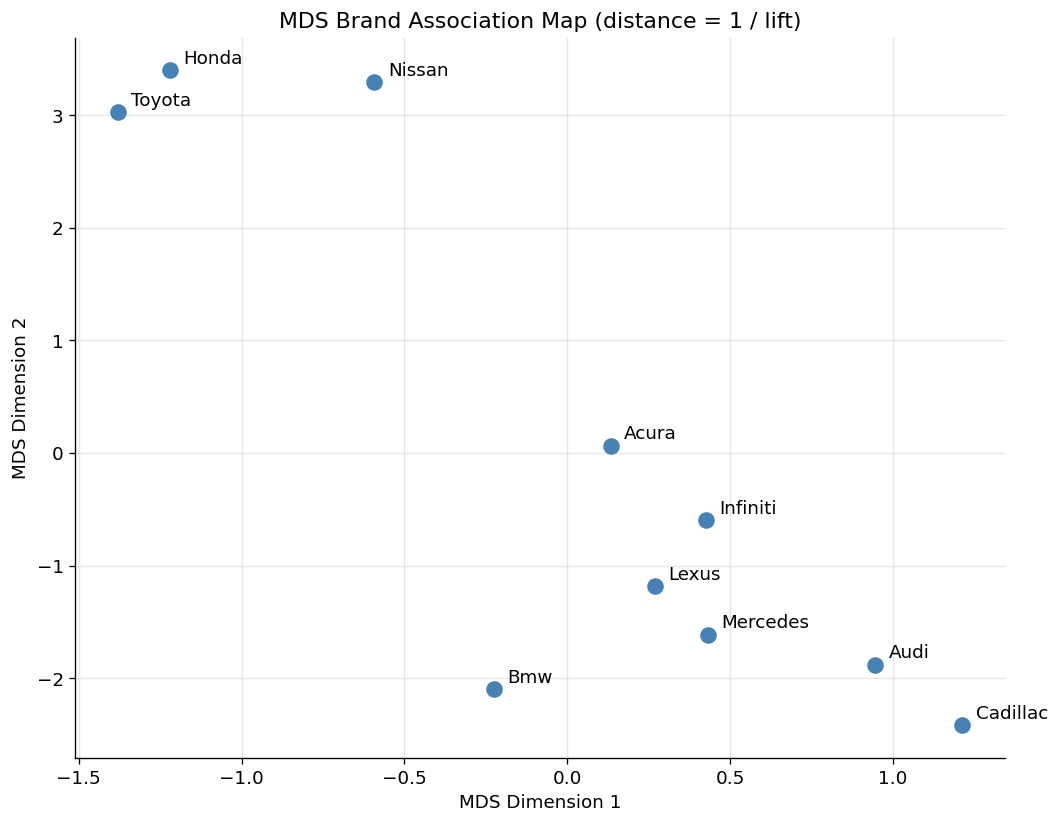

In [6]:
epsilon = 1e-6
distance_matrix = 1 / (lift_top10.values + epsilon)
np.fill_diagonal(distance_matrix, 0)  # self-distance is zero

mds    = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(distance_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=80, color='steelblue', zorder=3)
for i, brand in enumerate(top_10):
    ax.annotate(
        brand.title(), (coords[i, 0], coords[i, 1]),
        textcoords='offset points', xytext=(8, 4), fontsize=11
    )
ax.set_title('MDS Brand Association Map (distance = 1 / lift)')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The MDS map reveals three distinct perceptual groupings consistent with the lift matrix.

**Japanese mainstream cluster (top left):** Toyota, Honda, and Nissan are isolated in the upper left, reflecting their exceptionally high pairwise lift values. Their separation from the rest of the map is the largest of any grouping, indicating that when consumers discuss these brands they are operating in a clearly distinct conversational context from the luxury segment discussion.

**Japanese luxury cluster (center):** Acura, Lexus, and Infiniti cluster together near the center of the map. These brands occupy a middle ground, more associated with each other than with the mainstream Japanese brands, but also closer to the European luxury brands than Toyota or Honda are.

**European and domestic luxury cluster (bottom right):** Mercedes, Audi, Cadillac, and BMW sit in the lower right. Cadillac and Audi are the most tightly paired in this group, consistent with their lift value of 2.22. BMW sits somewhat apart from the others despite sharing the quadrant, reinforcing the earlier finding that it functions more as a standalone benchmark than as a direct comparison target.

The horizontal axis broadly separates mainstream from luxury, while the vertical axis separates the Japanese brands from the European and domestic ones.

## 7. Attribute-Brand Lift Analysis

To identify which attributes consumers associate with each brand, we apply the same lift formula used for brand pairs computed between brand tokens and attribute tokens at the post level.

The attribute vocabulary is organized into five categories: performance, comfort and features, price and value, reliability, and appearance. Each attribute is matched as an exact token after punctuation stripping and lowercasing. We first identify the 5 most frequently mentioned attributes across the corpus, then compute lift between each of those attributes and each of the top 10 brands.

Lift values are shown as raw numbers in the annotations. The heatmap shading is normalized within each brand so that relative strength of association is visible across brands with different baseline mention frequencies.

Top 5 most-mentioned attributes: ['performance', 'luxury', 'price', 'engine', 'seat']


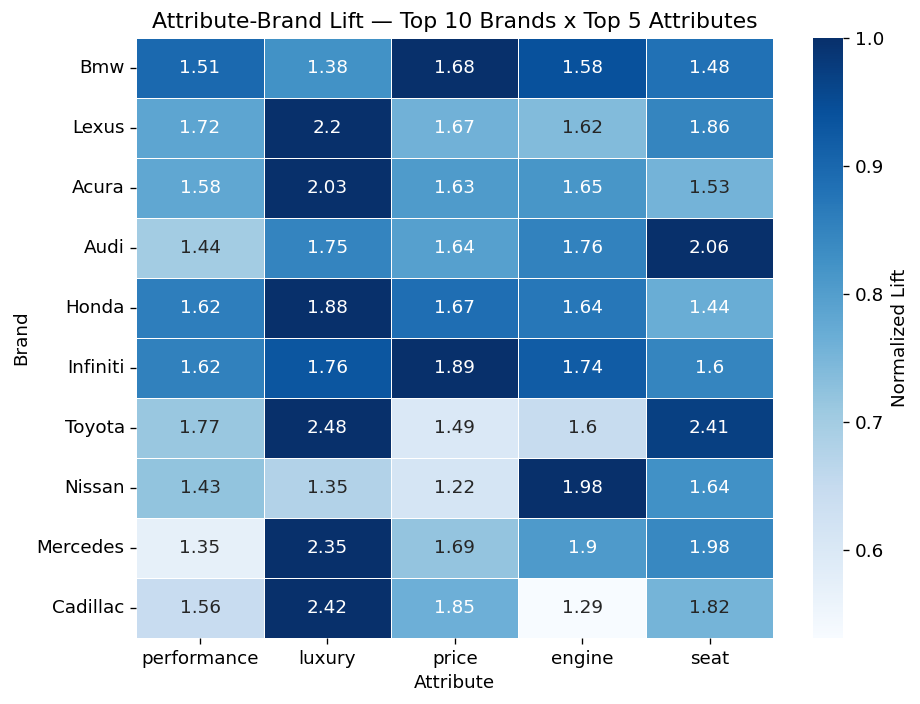

In [7]:
# ── Attribute vocabulary (deduplicated, organized by category) ────────────────
ATTRIBUTES = [
    # Performance
    'performance', 'speed', 'horsepower', 'engine', 'fast',
    # Comfort and features
    'comfort', 'comfortable', 'sunroof', 'seats', 'seat',
    'technology', 'gps', 'wireless',
    # Price and value
    'price', 'msrp', 'affordable', 'cheap', 'value', 'expensive', 'insurance',
    # Reliability
    'reliable', 'dependable', 'warranty', 'mileage', 'fuel', 'gas',
    # Appearance
    'luxury', 'wheels', 'wheel',
]

# ── Count post-level co-occurrences ───────────────────────────────────────────
attr_freq       = defaultdict(int)
brand_attr_freq = defaultdict(lambda: defaultdict(int))

for tokens in df['tokens']:
    brands_here = brands_in_tokens(tokens)
    attrs_here  = {t for t in tokens if t in ATTRIBUTES}

    for attr in attrs_here:
        attr_freq[attr] += 1
    for brand in brands_here:
        for attr in attrs_here:
            brand_attr_freq[brand][attr] += 1

# ── Top 5 attributes by total post frequency ─────────────────────────────────
top_5_attrs = [a for a, _ in sorted(attr_freq.items(),
                                     key=lambda x: x[1], reverse=True)[:5]]
print("Top 5 most-mentioned attributes:", top_5_attrs)

# ── Build lift matrix: top 10 brands x top 5 attributes ──────────────────────
rows = []
for brand in top_10:
    row = []
    for attr in top_5_attrs:
        joint  = brand_attr_freq[brand][attr]
        b_freq = post_brand_freq[brand]
        a_freq = attr_freq[attr]
        lift_val = (joint * N_POSTS) / (b_freq * a_freq) if b_freq > 0 and a_freq > 0 else 0.0
        row.append(lift_val)
    rows.append(row)

attr_lift_df = pd.DataFrame(rows, index=top_10, columns=top_5_attrs)

# ── Normalize within each brand for heatmap shading ──────────────────────────
attr_lift_norm = attr_lift_df.div(attr_lift_df.max(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    attr_lift_norm.rename(index=str.title),
    annot=attr_lift_df.rename(index=str.title).round(2),
    fmt='',
    cmap='Blues', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalized Lift'}
)
ax.set_title('Attribute-Brand Lift — Top 10 Brands x Top 5 Attributes')
ax.set_xlabel('Attribute')
ax.set_ylabel('Brand')
plt.tight_layout()
plt.show()

All lift values are above 1, meaning every brand in the top 10 is discussed in conjunction with all five attributes more than chance would predict. This is expected given the forum context: consumers shopping entry-level luxury sedans naturally discuss performance, luxury, price, engine, and seating across all brands they consider.

The more informative signal is the relative variation across brands:

**Luxury** shows the widest spread of any attribute. Toyota (2.48) and Cadillac (2.42) have the strongest luxury associations despite neither being a traditional European luxury b,nd — suggesting forum users are actively debating whether these brands belong in the luxury category, rather than taking it as given. Lexus (2.20) and Mercedes (2.35) follow closely. BMW has the weakest luxury association (1.38) relative to its other attributes, consistent with its positioning as a performance-first brand.

**Seat** is Audi's strongest attribute by a clear margin (2.06), and also prominent for Toyota (2.41) and Mercedes (1.98). Interior comfort and seating quality appear to be a key differentiator in how consumers discuss these brands.

**Engine** is Nissan's standout attribute (1.98), likely driven by forum discussion around the G35's VQ engine which received significant enthusiast attention during this period.

**Price** is most strongly associated with Infiniti (1.89) and Cadillac (1.85), suggesting consumers frequently discuss these brands in the context of value relative to their luxury positioning.

**Performance** lift is relatively uniform across brands, ranging from 1.35 to 1.77, indicating it is a baseline expectation discussed across the entire segment rather than a differentiator for any single brand.

## 8. Aspirational Brand Detection

An aspirational brand is one that consumers express a desire or intention to own. To detect this, we match bigram and short phrases signaling purchase intent against brand mentions at the post level, then compute lift between those phrases and each brand.

**Why phrases rather than single words?** Single tokens like "want" or "dream" appear in many contexts unrelated to brand aspiration ("I don't want this problem", "dream of a fix"). Multi-word phrases like "want to" or "dream car" more reliably capture genuine aspiration in conversational forum text. Phrases were selected to reflect both formal register ("would like", "hope to") and informal register ("really want", "love to", "can afford") since forum posts vary widely in tone.

The aspirational score for each brand is the median lift across all phrases, which is more robust than the mean to phrases that appear very rarely in the corpus.

infiniti      2.282584
lexus         2.032739
acura         1.829107
volvo         1.595322
toyota        1.578168
bmw           1.542498
ford          1.457813
audi          1.409744
volkswagen    1.385761
honda         1.382272
mercedes      1.373338
nissan        1.327313
subaru        1.139834
chevrolet     1.128819
mazda         0.871776
cadillac      0.812822
hyundai       0.554009
dodge         0.493892
lincoln       0.359609
buick         0.000000
chrysler      0.000000
kia           0.000000
mercury       0.000000
mitsubishi    0.000000
pontiac       0.000000
saturn        0.000000
suzuki        0.000000


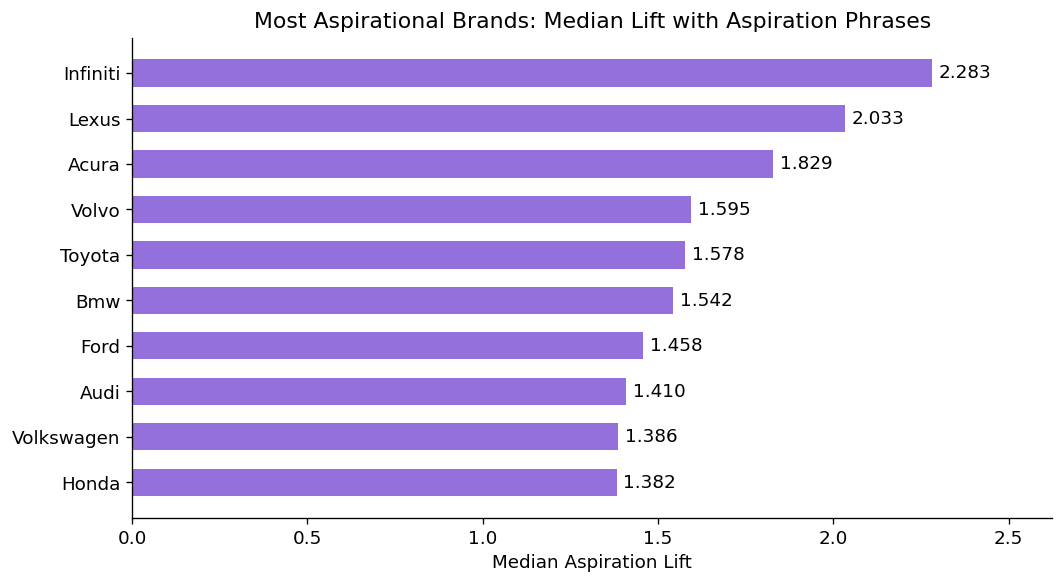

In [8]:
# ── Aspiration phrase list ─────────────────────────────────────────────────────
ASPIRATION_PHRASES = [
    'aim to', 'would like', 'looking for', 'really believe', 'really need',
    'hope for', 'really hope', 'wish to', 'dream car', 'aspire', 'hope to',
    'want to', 'looking to', 'really want', 'can afford', 'love to',
    'looking at', 'plan to', 'trying to', 'saving for',
]

# ── Count post-level co-occurrences ───────────────────────────────────────────
asp_freq       = defaultdict(int)
brand_asp_freq = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    text   = row['comment_clean']
    tokens = row['tokens']

    brands_here = brands_in_tokens(tokens)
    asps_here   = {phrase for phrase in ASPIRATION_PHRASES if phrase in text}

    for phrase in asps_here:
        asp_freq[phrase] += 1
    for brand in brands_here:
        for phrase in asps_here:
            brand_asp_freq[brand][phrase] += 1

# ── Build lift matrix: all brands x aspiration phrases ────────────────────────
all_brands_sorted = sorted(post_brand_freq.keys())

asp_rows = []
for brand in all_brands_sorted:
    row = []
    for phrase in ASPIRATION_PHRASES:
        joint  = brand_asp_freq[brand][phrase]
        b_freq = post_brand_freq[brand]
        p_freq = asp_freq[phrase]
        lift_val = (joint * N_POSTS) / (b_freq * p_freq) if b_freq > 0 and p_freq > 0 else 0.0
        row.append(lift_val)
    asp_rows.append(row)

asp_lift_df = pd.DataFrame(asp_rows, index=all_brands_sorted, columns=ASPIRATION_PHRASES)

# ── Median lift per brand ──────────────────────────────────────────────────────
median_asp_lift = (
    asp_lift_df.median(axis=1)
    .rename('Median Aspiration Lift')
    .sort_values(ascending=False)
)

print(median_asp_lift.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
top_asp = median_asp_lift.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    [b.title() for b in top_asp.index[::-1]],
    top_asp.values[::-1],
    color='mediumpurple', height=0.6
)
ax.bar_label(bars, padding=4, fmt='%.3f')
ax.set_xlabel('Median Aspiration Lift')
ax.set_title('Most Aspirational Brands: Median Lift with Aspiration Phrases')
ax.set_xlim(0, top_asp.max() * 1.15)
plt.tight_layout()
plt.show()

Infiniti emerges as the most aspirational brand with a median lift of 2.28, meaningfully ahead of second-place Lexus (2.03) and third-place Acura (1.83). This is notable given that Infiniti ranks sixth in raw mention volume. Consumers discuss it less frequently than BMW or Lexus overall, but when they do, aspiration phrases appear in the same post at a higher rate than any other brand. This suggests a concentrated segment of consumers who actively want to own an Infiniti rather than simply discussing it as a reference point.

Lexus and Acura round out the top three, forming a clear Japanese luxury aspirational tier. All three brands occupy the center cluster of the MDS map, suggesting that consumers who express purchase intent are disproportionately shopping this middle ground between mainstream Japanese reliability and European luxury pricing.

BMW, despite being the most-discussed brand in the corpus, ranks sixth on aspiration lift (1.54). High mention volume paired with moderate aspiration lift is consistent with BMW functioning as a benchmark that consumers compare against rather than a brand they express personal desire to own.

Eight brands (Buick, Chrysler, Kia, Mercury, Mitsubishi, Pontiac, Saturn, and Suzuki) recorded zero aspiration lift, meaning no post in the corpus contained both an aspiration phrase and a mention of these brands within the same discussion. Several of these are discontinued brands whose presence in the corpus reflects historical posts, which likely explains their absence from aspiration conversations.

## Key Findings

**Corpus structure:** The word frequency distribution follows a power-law broadly consistent with Zipf's law (theta = -2.61). The deviation from the theoretical -1 reflects the narrow, repetitive vocabulary of a domain-specific corpus rather than a data quality issue.

**Brand conversation volume:** BMW dominates raw discussion at 3,100 post ment, s — nearly three times the next brand. High mention volume does not translate directly to aspiration or co-mention lift, suggesting BMW functions as a conversational benchmark rather than an active purchase target.

**Competitive clusters:** Three groupings emerge from the lift and MDS analyses: a tight mainstream cluster of Toyota, Honda, and Nissan; a Japanese luxury cluster of Lexus, Acura, and Infiniti; and a European and domestic luxury cluster of Mercedes, Audi, Cadillac, and BMW.

**Attribute associations:** Luxury and seat are the most differentiating attributes across brands. Performance lift is uniform across all brands, indicating it is a baseline expectation for the segment rather than a differentiator for any single brand.

**Aspirational brand:** Infiniti leads on median aspiration lift (2.28), ahead of Lexus (2.03) and Acura (1.83). Its score is disproportionate to its mention volume, pointing to a concentrated segment of consumers with genuine purchase intent.ideration.